# <span style="color:green"> Script (from G.N) for testing all automatic thresholding methods in 3Dslicer to choose one before going to pipeline

# Load libraries

In [1]:
from pathlib import Path
import os
import slicer
import matplotlib.pyplot as plt
import pandas as pd
import pyslicer as ps
import numpy as np
import vtk.util.numpy_support

# Papermill parameters to be changed

In [2]:
# Specify the directory of microCT files (first .jpg file)
nrrd_file = "xx"

# select the best method 'HUANG', 'INTERMODES', 'ISO_DATA', 'KITTLER_ILLINGWORTH', 'LI', 'MAXIMUM_ENTROPY', 'MOMENTS', 'OTSU', 'RENYI_ENTROPY', 'SHANBHAG', 'TRIANGLE', 'YEN'
selected_method_1 = 'xx'

In [3]:
# Parameters
nrrd_file = "primitive_scaffold/primitive_0000_high-quality.nrrd"
selected_method_1 = "INTERMODES"


# Preparing directories

In [4]:
# Specify the parent path
path = Path(nrrd_file)
folder_path = path.parent.absolute()

# Prepare 3dSlicer and Import CT data

In [5]:
# Load the NRRD file
masterVolumeNode = slicer.util.loadVolume(nrrd_file)

# Create segmentationNode

## Create segmentation-related nodes

Create segmentation node

In [6]:
segmentationNode = ps.segmentation.segmentationNode(name='Segmentation')

Create temporary segment editor to get access to effects

In [7]:
segmentEditorWidget, segmentEditorNode = ps.segmentation.segmentEditorWidget(segmentationNode = segmentationNode, 
                                                                             masterVolumeNode = masterVolumeNode)

# Thresholding

## Check different automatic segmentation algorithms

The first time you analyze an image/channel. Go to the ```Segment Editor```, add a new segment and choose the thresholding method. There you test different automatic thresholding technique and choose the one working best. For later analysis, you can just copy the thresholding values in the ```segments_greyvalues``` object at the beginning of this notebook.

In [8]:
#ps.volume.plot_histogram(masterVolumeNode, yscale='log')

Get automatic thresholding values, as indicated in [this script](https://github.com/jzeyl/3D-Slicer-Scripts/blob/db51967cc642837e8bae0fea1585a95074d8420b/load_dicom_modified_otsu.py#L56)

## Perform the thresholding based on established 1st method

In [9]:
method = selected_method_1

selected_method_1_threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masterVolumeNode)

print(method + " threshold: " + str(selected_method_1_threshold))
#ps.volume.plot_histogram(masked_volume_node, threshold = threshold, title = method, yscale='log')

INTERMODES threshold: 101.61743545532227

In [10]:
# Get the vtkImageData from the volume node
image_data = masterVolumeNode.GetImageData()

# Convert vtkImageData to a numpy array
# Get the scalar values as a 1D array
scalars = image_data.GetPointData().GetScalars()
numpy_array = vtk.util.numpy_support.vtk_to_numpy(scalars)

# Compute the maximum value in the numpy array
max_value = np.max(numpy_array)

# new values for histogram after discarding whats before the threshold
segments_greyvalues = {
    "All": [selected_method_1_threshold, max_value], # [selected_method, MaxIntensity]
    }

segments_greyvalues

{'All': [101.61743545532227, 255]}

## Create segments by thresholding

In [11]:
ps.segmentation.segments_by_thresholding(segments_greyvalues, 
                                         segmentationNode,
                                         segmentEditorNode,
                                         segmentEditorWidget)

## Mask volume with segment mask

In [12]:
segment_name = 'All'
inputVolume = masterVolumeNode
operation = "FILL_OUTSIDE"
fill_value = 0

In [13]:
# example of using Mask volume effect from a Python script
# https://github.com/lassoan/SlicerSegmentEditorExtraEffects/blob/master/SegmentEditorSplitVolume/SegmentEditorSplitVolumeLib/SegmentEditorEffect.py#L129-L192

volumesLogic = slicer.modules.volumes.logic()

import SegmentEditorEffects
maskVolumeWithSegment = SegmentEditorEffects.SegmentEditorMaskVolumeEffect.maskVolumeWithSegment

scene = inputVolume.GetScene()
outputVolumeName = inputVolume.GetName() + '_masked'
outputVolume = volumesLogic.CloneVolumeGeneric(scene, inputVolume, outputVolumeName, False)
segmentation = segmentationNode.GetSegmentation()
sourceSegmentId = segmentation.GetSegmentIdBySegmentName(segment_name)


maskVolumeWithSegment(segmentationNode = segmentationNode, 
                      segmentID = sourceSegmentId, 
                      operationMode = operation, 
                      fillValues = [fill_value], 
                      inputVolumeNode = inputVolume, 
                      outputVolumeNode = outputVolume)

True

In [14]:
masked_volume_node = outputVolume

Delete `All` segment before computing volumes

In [15]:
segmentName = 'All'
segmentId = segmentationNode.GetSegmentation().GetSegmentIdBySegmentName(segmentName)
segmentationNode.GetSegmentation().RemoveSegment('1')

## Check different automatic segmentation algorithms

The first time you analyze an image/channel. Go to the ```Segment Editor```, add a new segment and choose the thresholding method. There you test different automatic thresholding technique and choose the one working best. For later analysis, you can just copy the thresholding values in the ```segments_greyvalues``` object at the beginning of this notebook.

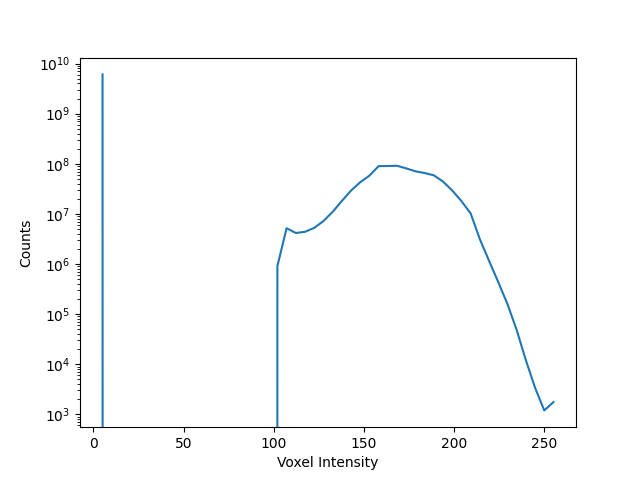

In [16]:
ps.volume.plot_histogram(masked_volume_node, yscale='log')

In [17]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/2/intensities_2.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

Get automatic thresholding values, as indicated in [this script](https://github.com/jzeyl/3D-Slicer-Scripts/blob/db51967cc642837e8bae0fea1585a95074d8420b/load_dicom_modified_otsu.py#L56)

In [18]:
methods = [
            'HUANG',
            'INTERMODES',
            'ISO_DATA',
            'KITTLER_ILLINGWORTH',
            'LI',
            'MAXIMUM_ENTROPY',
            'MOMENTS',
            'OTSU',
            'RENYI_ENTROPY',
            'SHANBHAG',
            'TRIANGLE',
            'YEN'
            ]

thresholds = dict.fromkeys(methods, None)
thresholds

{'HUANG': None,
 'INTERMODES': None,
 'ISO_DATA': None,
 'KITTLER_ILLINGWORTH': None,
 'LI': None,
 'MAXIMUM_ENTROPY': None,
 'MOMENTS': None,
 'OTSU': None,
 'RENYI_ENTROPY': None,
 'SHANBHAG': None,
 'TRIANGLE': None,
 'YEN': None}

Otsu thresholding

OTSU threshold: 3.984997510910034

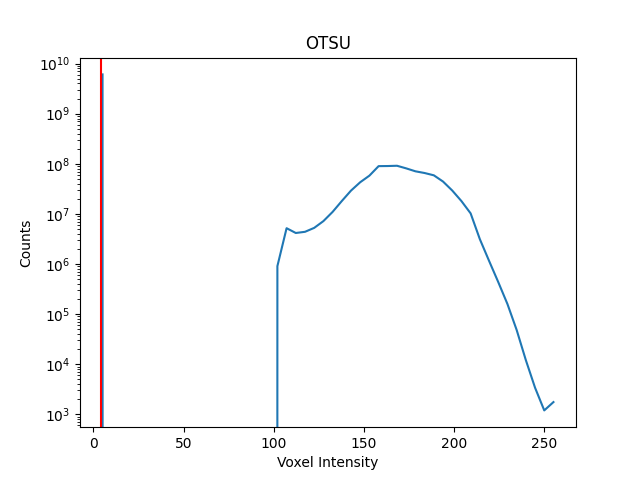

In [19]:
method = 'OTSU'

threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masked_volume_node)

thresholds[method.upper()] = threshold

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masked_volume_node, threshold = threshold, title = method, yscale='log')

In [20]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/2/OTSU_2.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

Huang thresholding

HUANG threshold: 1.992498755455017

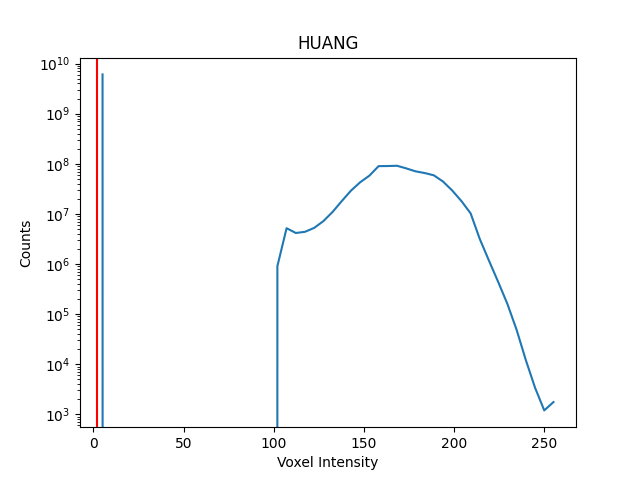

In [21]:
method = 'HUANG'

threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masked_volume_node)

thresholds[method.upper()] = threshold

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masked_volume_node, threshold = threshold, title = method, yscale='log')

In [22]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/2/HUANG_2.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

IsoData thresholding

ISO_DATA threshold: 101.61743545532227

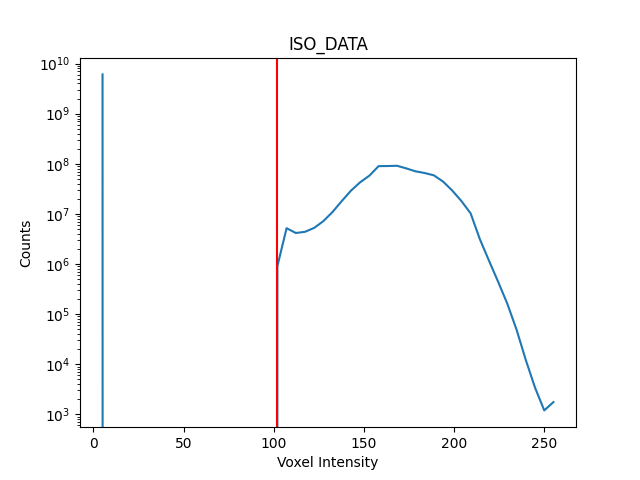

In [23]:
method = 'ISO_DATA'

threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masked_volume_node)

thresholds[method.upper()] = threshold

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masked_volume_node, threshold = threshold, title = method, yscale='log')

In [24]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/2/ISO_DATA_2.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

MAXIMUM_ENTROPY thresholding

MAXIMUM_ENTROPY threshold: 253.0473419189453

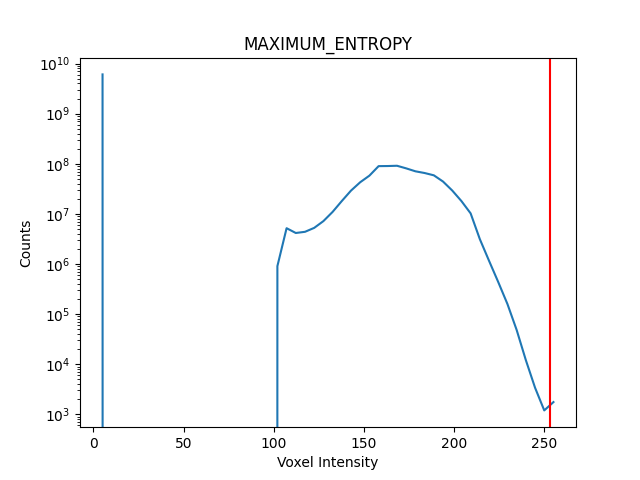

In [25]:
method = 'MAXIMUM_ENTROPY'

threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masked_volume_node)

thresholds[method.upper()] = threshold

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masked_volume_node, threshold = threshold, title = method, yscale='log')

In [26]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/2/MAXIMUM_ENTROPY_2.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

MOMENTS thresholding

MOMENTS threshold: 129.5124168395996

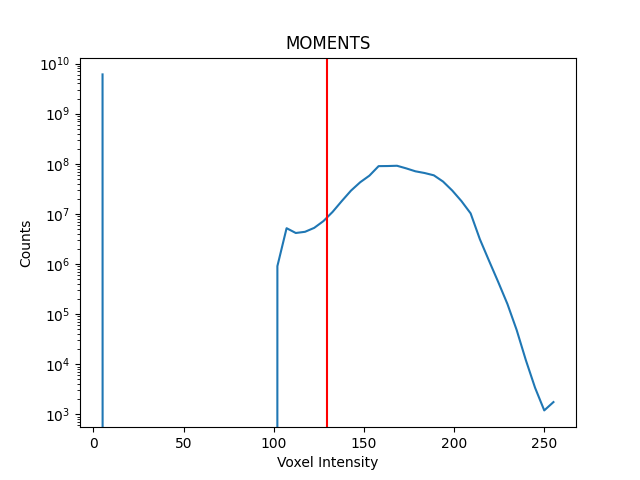

In [27]:
method = 'MOMENTS'

threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masked_volume_node)

thresholds[method.upper()] = threshold

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masked_volume_node, threshold = threshold, title = method, yscale='log')

In [28]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/2/MOMENTS_2.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

INTERMODES thresholding

INTERMODES threshold: 133.4974136352539

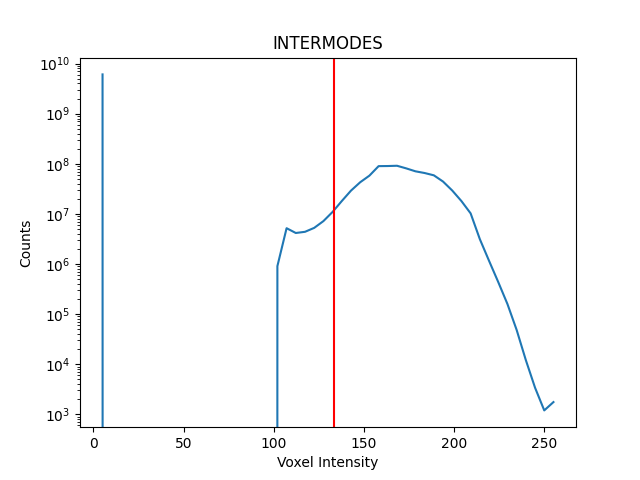

In [29]:
method = 'INTERMODES'

threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masked_volume_node)

thresholds[method.upper()] = threshold

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masked_volume_node, threshold = threshold, title = method, yscale='log')

In [30]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/2/INTERMODES_2.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

LI threshold: 6.678634761226283e-307

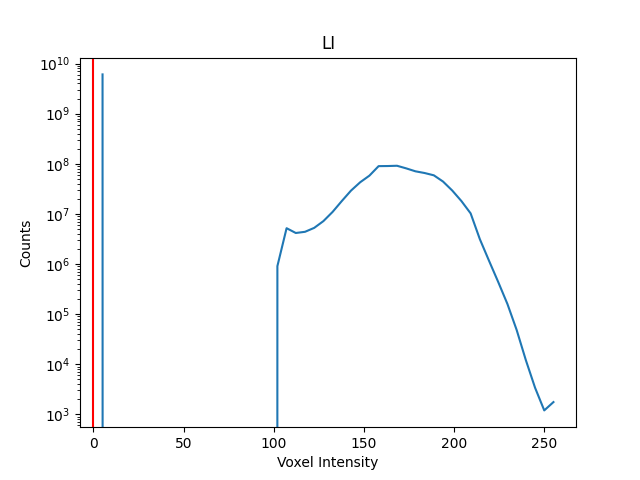

In [31]:
method = 'LI'

threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masked_volume_node)

thresholds[method.upper()] = threshold

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masked_volume_node, threshold = threshold, title = method, yscale='log')

In [32]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/2/LI_2.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

KITTLER_ILLINGWORTH threshold: 0.0

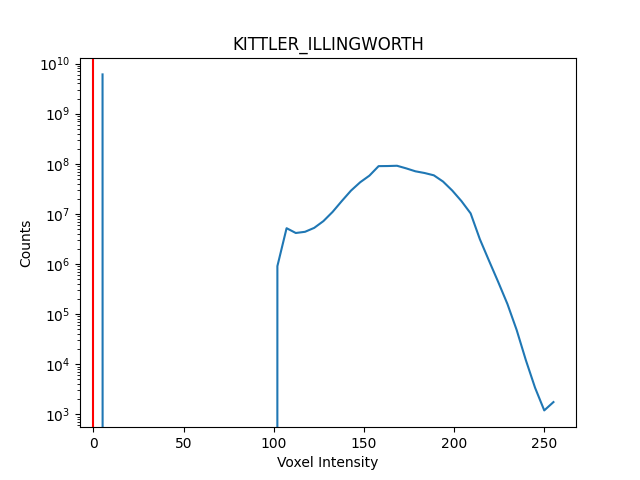

In [33]:
method = 'KITTLER_ILLINGWORTH'

threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masked_volume_node)

thresholds[method.upper()] = threshold

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masked_volume_node, threshold = threshold, title = method, yscale='log')

In [34]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/2/KITTLER_ILLINGWORTH_2.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

RENYI_ENTROPY threshold: 17.932488918304443

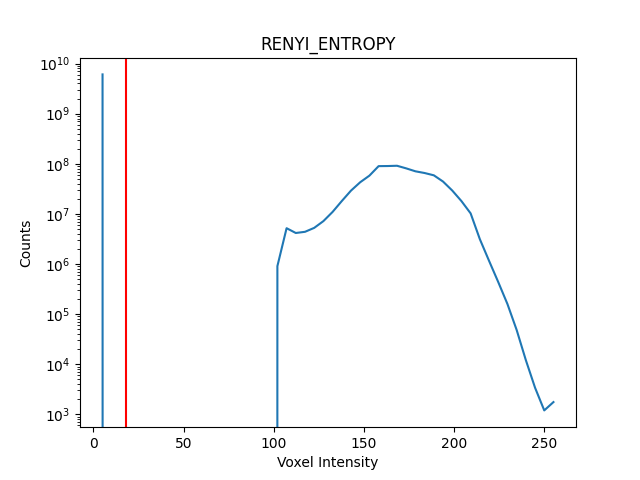

In [35]:
method = 'RENYI_ENTROPY'

threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masked_volume_node)

thresholds[method.upper()] = threshold

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masked_volume_node, threshold = threshold, title = method, yscale='log')

In [36]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/2/RENYI_ENTROPY_2.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

SHANBHAG threshold: 253.0473419189453

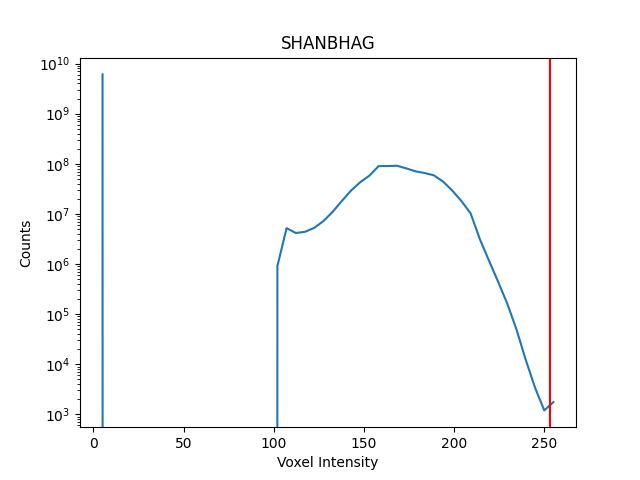

In [37]:
method = 'SHANBHAG'

threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masked_volume_node)

thresholds[method.upper()] = threshold

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masked_volume_node, threshold = threshold, title = method, yscale='log')

In [38]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/2/SHANBHAG_2.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

YEN threshold: 249.06233978271484

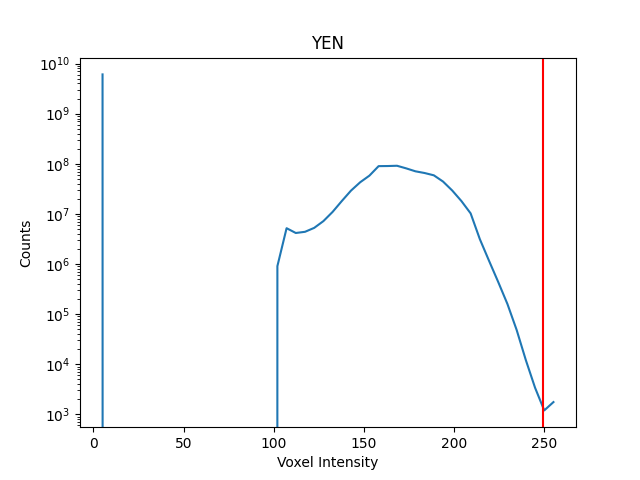

In [39]:
method = 'YEN'

threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masked_volume_node)

thresholds[method.upper()] = threshold

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masked_volume_node, threshold = threshold, title = method, yscale='log')

In [40]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/2/YEN_2.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

TRIANGLE threshold: 9.962493658065796

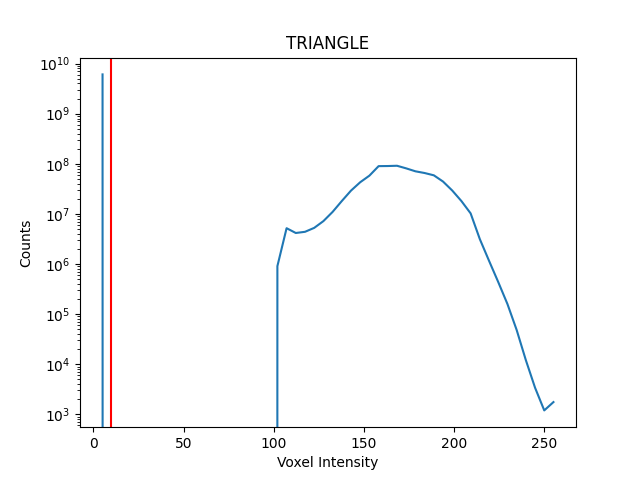

In [41]:
method = 'TRIANGLE'

threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masked_volume_node)

thresholds[method.upper()] = threshold

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masked_volume_node, threshold = threshold, title = method, yscale='log')

In [42]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/2/TRIANGLE_2.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

## Select thresholding values

In [43]:
thresholds_2 = thresholds
thresholds_2

{'HUANG': 1.992498755455017,
 'INTERMODES': 133.4974136352539,
 'ISO_DATA': 101.61743545532227,
 'KITTLER_ILLINGWORTH': 0.0,
 'LI': 6.678634761226283e-307,
 'MAXIMUM_ENTROPY': 253.0473419189453,
 'MOMENTS': 129.5124168395996,
 'OTSU': 3.984997510910034,
 'RENYI_ENTROPY': 17.932488918304443,
 'SHANBHAG': 253.0473419189453,
 'TRIANGLE': 9.962493658065796,
 'YEN': 249.06233978271484}

## Save the data as txt file

In [44]:
output_file = folder_path / 'thresholding/automatic_thresholding.txt'
# Ensure the directory exists
output_file.parent.mkdir(parents=True, exist_ok=True)

# Write the content to the file
with open(output_file, 'a') as file:
    file.write(f"\nthresholds_2:\n{thresholds_2}\n")


In [45]:
# Define a list of 12 distinct colors
colors = [
    '#FF5733',  # Red-Orange
    '#33FF57',  # Green
    '#3357FF',  # Blue
    '#FF33B5',  # Pink
    '#B533FF',  # Purple
    '#33FFF3',  # Cyan
    '#FFAF33',  # Orange
    '#9AFF33',  # Lime
    '#FF3333',  # Red
    '#5733FF',  # Indigo
    '#FFDD33',  # Yellow
    '#FF33F1',  # Magenta
]

# Plotting the histogram
ps.volume.plot_histogram(masked_volume_node, yscale='log')

# Getting the current axis object
ax = plt.gca()

# Getting the min and max values of the x-axis (intensity values)
min_value, max_value = ax.get_xlim()

# Adding vertical lines for each threshold with distinct colors
for index, (method, threshold) in enumerate(thresholds_2.items()):
    if min_value <= threshold <= max_value:
        plt.axvline(x=threshold, label=f'{method}: {threshold:.2f}', linestyle='--', color=colors[index], alpha=0.7)

# Customizing the plot
plt.xlabel('Intensity Value')
plt.ylabel('Frequency (Log Scale)')
plt.title('Histogram with Thresholds')
plt.legend(loc='upper right', fontsize='small')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Save the plot
plt.savefig(folder_path / 'thresholding/all2.png')
